In [12]:
import pandas as pd

women = pd.read_csv(
    "../data/Cyber Crime Against Women in 2020.csv"
)

In [ ]:
women.head()

women.shape

women.columns

women.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column                                                              Non-Null Count  Dtype 
---  ------                                                              --------------  ----- 
 0   State                                                               36 non-null     object
 1   Cyber Blackmailing / Threatening                                    36 non-null     int64 
 2   Cyber Pornography / Hosting / Publishing Obscene Sexual Materials
  36 non-null     int64 
 3   Cyber Stalking / Cyber Bullying of Women
                           36 non-null     int64 
 4   Defamation / Morphing
                                              36 non-null     int64 
 5   Fake Profile
                                                       36 non-null     int64 
 6   Other Crimes against Women                                          36 non-null     int64 
 7   Total Cyber Crimes against Wo

: 

In [4]:
women.sort_values(
    by='Total Cyber Crimes against Women',
    ascending=False
)[['State','Total Cyber Crimes against Women']].head(10)

,State,Total Cyber Crimes against Women
0,Karnataka,2859
1,Maharashtra,1632
2,Assam,1071
3,Uttar Pradesh,749
4,Telangana,649
5,Odisha,560
6,Andhra Pradesh,375
7,West Bengal,344
8,Tamil Nadu,306
9,Gujarat,277


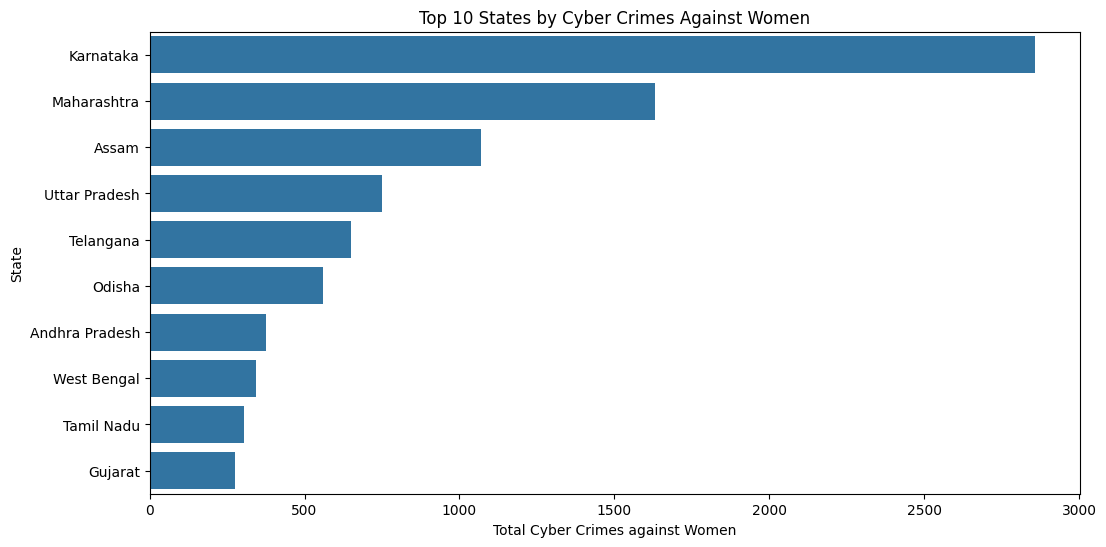

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_women = women.sort_values(
    by='Total Cyber Crimes against Women',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_women,
    x='Total Cyber Crimes against Women',
    y='State'
)

plt.title(
    'Top 10 States by Cyber Crimes Against Women'
)

plt.show()

In [6]:
crime_types = women.drop(
    columns=[
        'State',
        'Total Cyber Crimes against Women'
    ]
)

crime_totals = crime_types.sum()

crime_totals.sort_values(
    ascending=False
)

Other Crimes against Women                                             7184
Cyber Pornography / Hosting / Publishing Obscene Sexual Materials\n    1655
Cyber Stalking / Cyber Bullying of Women\n                              887
Fake Profile\n                                                          354
Defamation / Morphing\n                                                 251
Cyber Blackmailing / Threatening                                         74
dtype: int64

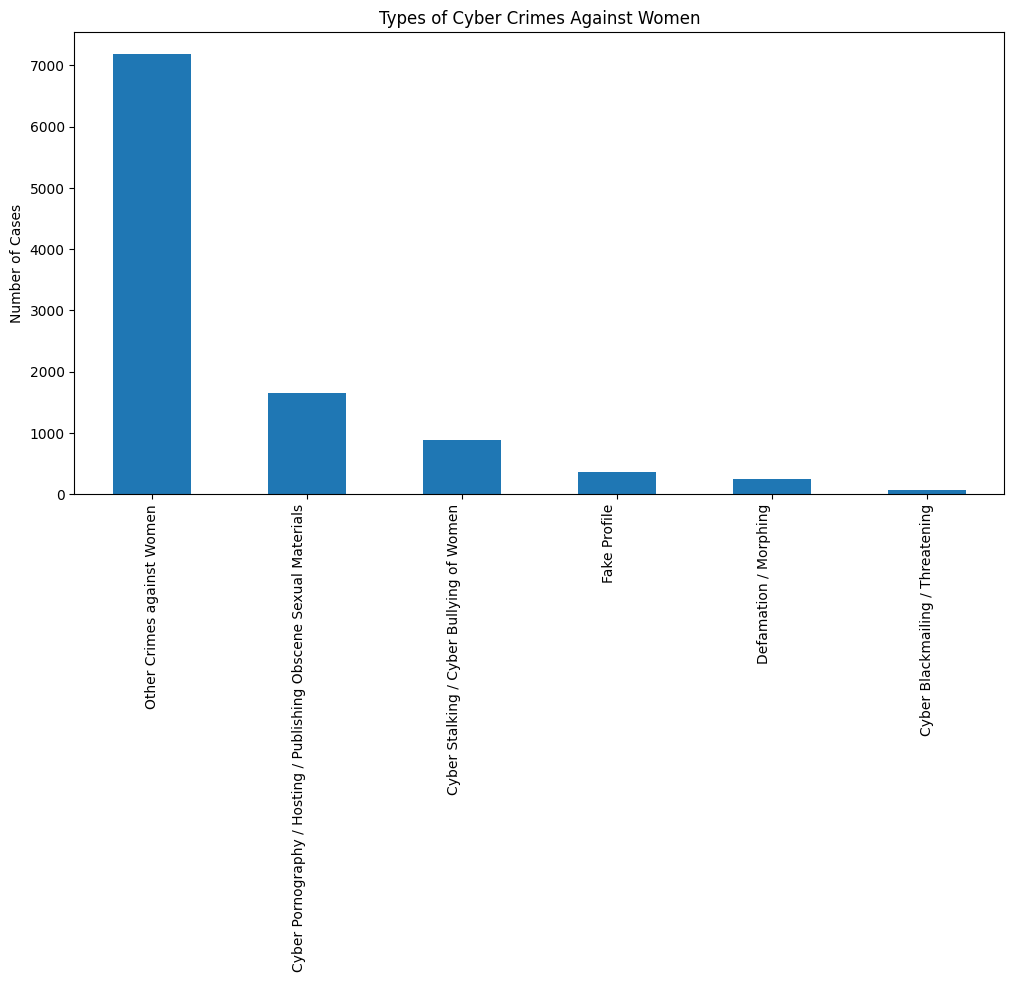

In [7]:
plt.figure(figsize=(12,6))

crime_totals.sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title(
    'Types of Cyber Crimes Against Women'
)

plt.ylabel('Number of Cases')

plt.show()

In [8]:
crime_percentage = (
    crime_totals /
    crime_totals.sum()
)*100

crime_percentage.sort_values(
    ascending=False
)

Other Crimes against Women                                             69.043729
Cyber Pornography / Hosting / Publishing Obscene Sexual Materials\n    15.905815
Cyber Stalking / Cyber Bullying of Women\n                              8.524748
Fake Profile\n                                                          3.402210
Defamation / Morphing\n                                                 2.412302
Cyber Blackmailing / Threatening                                        0.711197
dtype: float64

In [9]:
women['Women_Risk_Score'] = (
    women['Total Cyber Crimes against Women']
    /
    women['Total Cyber Crimes against Women'].max()
) * 100

In [10]:
women.sort_values(
    by='Women_Risk_Score',
    ascending=False
)[['State','Women_Risk_Score']].head(10)

,State,Women_Risk_Score
0,Karnataka,100.000000
1,Maharashtra,57.082896
2,Assam,37.460651
3,Uttar Pradesh,26.197971
4,Telangana,22.700245
5,Odisha,19.587268
6,Andhra Pradesh,13.116474
7,West Bengal,12.032179
8,Tamil Nadu,10.703043
9,Gujarat,9.688702


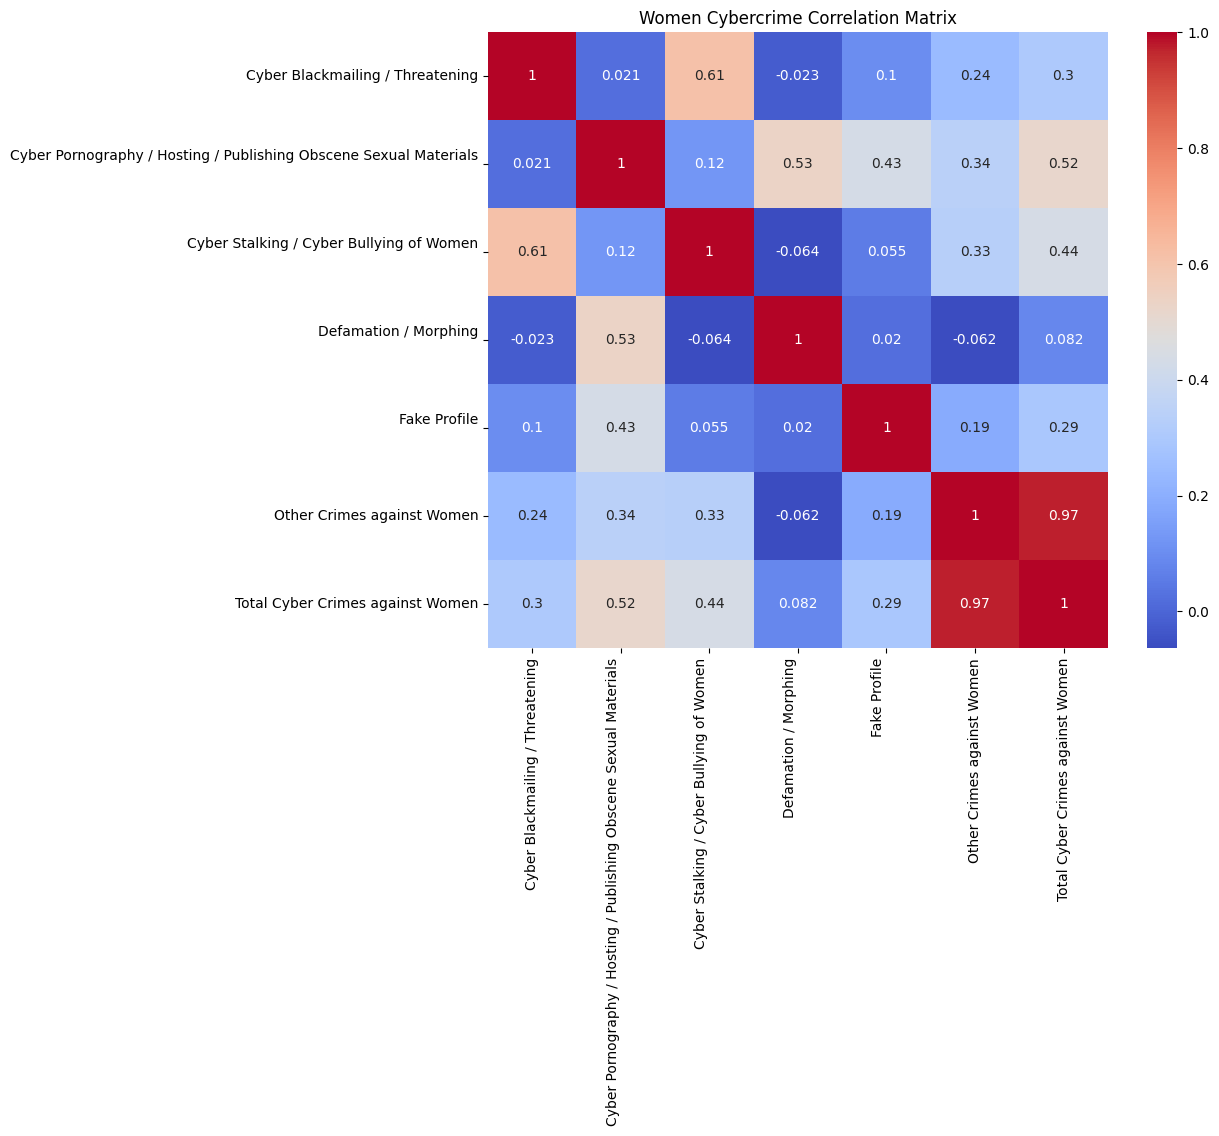

In [11]:
numeric_cols = women.select_dtypes(
    include=['int64']
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Women Cybercrime Correlation Matrix'
)

plt.show()